# **Spam Email Classification**

# NLP-Based Spam Email Classification Using TF-IDF and Multinomial Naive Bayes

### Self-Study Project – Natural Language Processing

**Programming Language:** Python  
**Platform:** Google Colab  
**NLP Technique:** TF-IDF  
**Machine Learning Algorithm:** Multinomial Naive Bayes  
**Problem Type:** Text Classification

## 1. Problem Identification

Spam emails are unwanted messages that may contain advertisements,
fraudulent content, malicious links, or irrelevant information.

The objective of this project is to develop an NLP-based machine
learning system that automatically classifies email messages into
two categories:

- Spam
- Ham (Not Spam)

The system analyzes the textual content of an email and predicts
whether the message is spam or legitimate.

## 2. Problem Relevance

Spam email is a common problem for email users and organizations.
Manually identifying unwanted emails is time-consuming and can result
in important messages being missed.

Natural Language Processing is suitable for this problem because
emails contain textual information. NLP techniques can convert the
text into numerical features that can be processed by machine
learning algorithms.

The proposed system can help:

- Email users
- Organizations
- Email service providers
- Automated email filtering systems

The system can potentially be integrated into an email filtering
application to automatically identify unwanted messages.

## 3. Objectives

The main objectives of this project are:

1. To understand the problem of spam email classification.
2. To obtain a suitable spam and ham text dataset from Kaggle.
3. To preprocess the email text using NLP techniques.
4. To convert text into numerical features using TF-IDF.
5. To train a Multinomial Naive Bayes classification model.
6. To classify emails as spam or ham.
7. To evaluate the performance using Accuracy, Precision, Recall,
   F1-score, and Confusion Matrix.
8. To analyze the limitations and possible improvements of the system.

## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


## Download NLTK resources
We will use these for text preprocessing.

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Upload your Kaggle dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
print(uploaded.keys())

dict_keys(['dataset.zip'])


### Load the dataset




In [ ]:
df = pd.read_csv('dataset.zip')
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


## Understand your dataset

Why are we doing this?

Because we should not guess the column names.

In [ ]:
print("Dataset Shape:", df.shape)
print("Column Names:")
print(df.columns.tolist())
df.info()
df.isnull().sum()
df.describe(include='all')

Dataset Shape: (83448, 2)
Column Names:
['label', 'text']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


,label,text
count,83448.000000,83448
unique,NaN,83446
top,NaN,unsubscribe
freq,NaN,2
mean,0.526196,NaN
std,0.499316,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,1.000000,NaN
75%,1.000000,NaN


## Dataset description

The dataset used for this project was obtained from Kaggle.


**Source:** Kaggle



**Important Attributes:**

- Email/Text: Contains the textual content of the message.
- Label: Indicates whether the message is spam or ham.

**Target Variable:** Label

**Classes:**

- Spam
- Ham

The dataset is suitable for this project because it contains textual
messages along with their corresponding classification labels.

## Check the class distribution
This tells us whether the dataset is balanced or imbalanced.

label
1    43910
0    39538
Name: count, dtype: int64


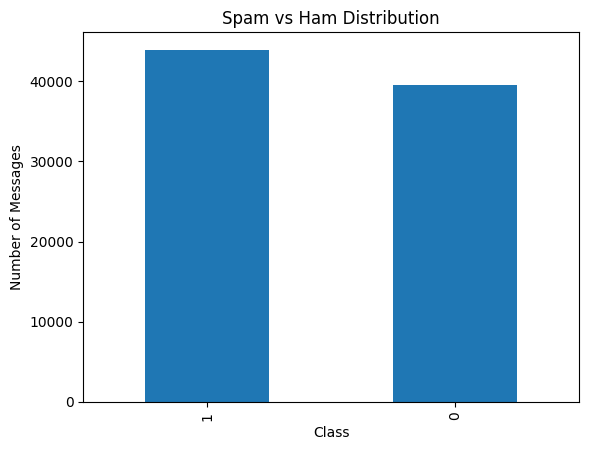

In [ ]:
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Messages')
plt.show()

## Check duplicate messages

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Remove duplicates:

In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (83448, 2)


## Handle missing values

In [ ]:
print(df.isnull().sum())

label    0
text     0
dtype: int64


In [ ]:
df = df.dropna(subset=['text'])

## Text preprocessing

In [ ]:
def clean_text(text):
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

## See before and after preprocessing

In [ ]:
print("Original:")
print(df['text'].iloc[0])

print("\nCleaned:")
print(df['clean_text'].iloc[0])

Original:
ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage

Cleaned:
ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage


Prepare X and y

X = Email text

y = Spam/Ham label

In [ ]:
X = df['clean_text']
y = df['label']

In [ ]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
0    ounce feather bowl hummingbird opec moment ala...
1    wulvob get your medircations online qnb ikud v...
2    computer connection from cnn com wednesday esc...
3    university degree obtain a prosperous future m...
4    thanks for all your answers guys i know i shou...
Name: clean_text, dtype: object

Target:
0    1
1    1
2    0
3    1
4    0
Name: label, dtype: int64


## Convert labels if necessary

In [30]:
y = y.map({'ham': 0, 'spam': 1})
print(y.value_counts())

Series([], Name: count, dtype: int64)


## Train/Test Split
Why?

The model learns from the training data and is then tested on data it has not seen before.


In [32]:
y = df['label'] # Re-initialize y from the original DataFrame
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 66758
Testing samples: 16690


## TF-IDF Vectorization

25. What is TF-IDF?

You should understand this for your viva.

TF-IDF = Term Frequency–Inverse Document Frequency

It converts text into numerical values.

For example:

"Congratulations you won a prize"

becomes numerical features.

TF-IDF gives greater importance to words that are useful for distinguishing documents.



In [34]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

In [36]:
#Train the vectorizer:
X_train_tfidf = tfidf.fit_transform(X_train)
#Transform the test data:
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (66758, 5000)
Testing TF-IDF shape: (16690, 5000)


## Train Multinomial Naive Bayes

In [37]:
model = MultinomialNB()
#train
model.fit(X_train_tfidf, y_train)
print("Model training completed!")

Model training completed!


## Make predictions

In [38]:
y_pred = model.predict(X_test_tfidf)
print(y_pred[:20])

[1 0 1 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0]


## Accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
#show in percentage
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 0.964469742360695
Accuracy: 96.45%


## Precision

In [41]:
precision = precision_score(y_test, y_pred, pos_label=1)

print("Precision:", precision)

Precision: 0.9748347442885307


## Recall

In [42]:
recall = recall_score(y_test, y_pred, pos_label=1)

print("Recall:", recall)

Recall: 0.9571851514461398


## F1-score

In [43]:
f1 = f1_score(y_test, y_pred, pos_label=1)

print("F1-score:", f1)

F1-score: 0.9659293306521115


## Display all metrics together

In [44]:
print("Model Evaluation")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Model Evaluation
-------------------------
Accuracy : 0.964469742360695
Precision: 0.9748347442885307
Recall   : 0.9571851514461398
F1-score : 0.9659293306521115


## Classification Report

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7908
           1       0.97      0.96      0.97      8782

    accuracy                           0.96     16690
   macro avg       0.96      0.96      0.96     16690
weighted avg       0.96      0.96      0.96     16690



## Confusion Matrix

In [46]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7691  217]
 [ 376 8406]]


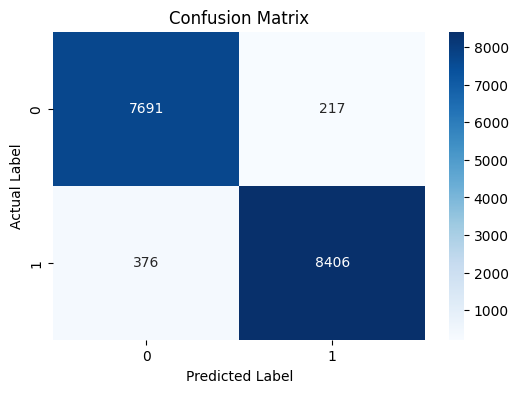

In [47]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Sample spam/ham predictions

In [48]:
sample_messages = [
    "Congratulations! You have won a free prize. Click here to claim now.",
    "Hi, can we meet tomorrow to discuss the project?",
    "You have been selected for a cash reward. Claim your money now!",
    "Please send me the assignment document before tomorrow."
]

In [57]:
#Clean them:
clean_samples = [clean_text(message) for message in sample_messages]
#Convert to TF-IDF:
sample_tfidf = tfidf.transform(clean_samples)
#Predict:
predictions = model.predict(sample_tfidf)
for message, prediction in zip(sample_messages, predictions):
    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    print("Message:", message)
    print("Prediction:", result)
    print("-" * 60)

Message: Congratulations! You have won a free prize. Click here to claim now.
Prediction: SPAM
------------------------------------------------------------
Message: Hi, can we meet tomorrow to discuss the project?
Prediction: HAM
------------------------------------------------------------
Message: You have been selected for a cash reward. Claim your money now!
Prediction: SPAM
------------------------------------------------------------
Message: Please send me the assignment document before tomorrow.
Prediction: HAM
------------------------------------------------------------


Message: Congratulations! You have won a free prize. Click here to claim now.
Prediction: SPAM
------------------------------------------------------------
Message: Hi, can we meet tomorrow to discuss the project?
Prediction: HAM
------------------------------------------------------------
Message: You have been selected for a cash reward. Claim your money now!
Prediction: SPAM
------------------------------------------------------------
Message: Please send me the assignment document before tomorrow.
Prediction: HAM
------------------------------------------------------------


## Results section

Results

The Multinomial Naive Bayes model was trained using TF-IDF features
extracted from the email text.

The performance of the model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The obtained results demonstrate how effectively the model can
distinguish between spam and legitimate messages.

## Results graph

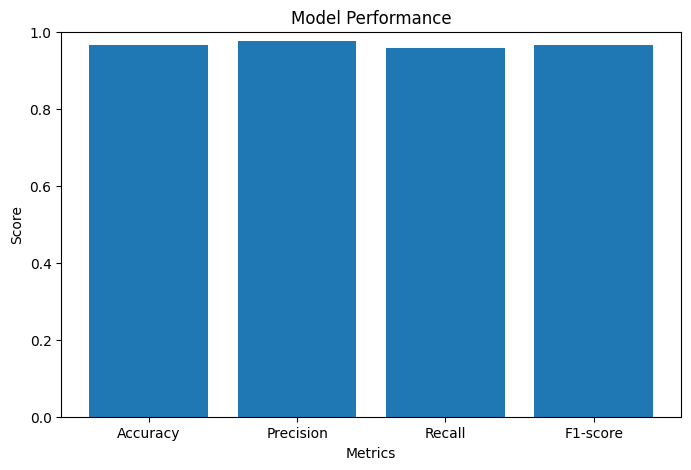

In [53]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))

plt.bar(metrics, values)

plt.title('Model Performance')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.show()

## Limitations


The project has some limitations:

1. The model depends on the quality and diversity of the dataset.
2. New types of spam emails may not always be classified correctly.
3. The system mainly relies on textual information.
4. Images and other non-textual content inside emails are not analyzed.
5. Spam messages containing unusual or previously unseen vocabulary
   may be difficult to classify.
6. The model may perform differently on datasets from different domains.

## Future Scope


The project can be improved in the future by:

1. Using a larger and more diverse email dataset.
2. Applying more advanced NLP preprocessing techniques.
3. Comparing Naive Bayes with Logistic Regression, SVM, and Random Forest.
4. Exploring deep learning and Transformer-based models.
5. Supporting multiple languages.
6. Developing a real-time spam detection system.
7. Deploying the model as a web application.
8. Integrating the system with an email service.

## Conclusion



This project developed an NLP-based spam email classification system
using TF-IDF and Multinomial Naive Bayes.

The email text was first cleaned and preprocessed. TF-IDF was then
used to convert the textual data into numerical features. A
Multinomial Naive Bayes classifier was trained using these features
to classify messages as spam or ham.

The model was evaluated using Accuracy, Precision, Recall, F1-score,
and Confusion Matrix.

This project helped demonstrate how Natural Language Processing and
Machine Learning can be combined to solve a practical text
classification problem.